In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
user_home = os.environ['HOME']
print(user_home)




/home/dejuns


In [9]:
save_dir = Path(f'{user_home}/git/stoic2021/data/STOIC2021Round1')
info_fp = save_dir/f'stoic2021_case_info_split.csv'
info_tb = pd.read_csv(info_fp)
info_tb.set_index('PatientID', inplace=True)
print(info_tb.describe())
print(info_tb.columns)


         probCOVID  probSevere  SliceThickness        split
count  2000.000000  2000.00000     2000.000000  2000.000000
mean      0.602500     0.15050        1.092200     2.000000
std       0.489503     0.35765        0.502086     1.414567
min       0.000000     0.00000        0.500000     0.000000
25%       0.000000     0.00000        0.750000     1.000000
50%       1.000000     0.00000        1.000000     2.000000
75%       1.000000     0.00000        1.250000     3.000000
max       1.000000     1.00000        5.000000     4.000000
Index(['probCOVID', 'probSevere', 'ITK_InputFilterName',
       'ITK_original_direction', 'ITK_original_spacing', 'PatientAge',
       'PatientName', 'PatientSex', 'SliceThickness', 'img_path', 'old_shape',
       'old_spacing', 'resize_shape', 'new_shape', 'new_spacing',
       'body_center', 'split'],
      dtype='object')


In [ ]:
std_age = lambda x: int(x[1:-1]) if len(x) > 2 else int(x)
info_tb['PatientAge'] = info_tb['PatientAge'].apply(std_age)

In [ ]:
covid_by_age = pd.crosstab(info_tb['PatientAge'], info_tb['probCOVID'])
print(covid_by_age)
ax_age = covid_by_age.plot.bar(rot = 0, stacked = True, width=3)


In [ ]:

severe_by_age = pd.crosstab(info_tb['PatientAge'], info_tb['probSevere'])
print(severe_by_age)
ax_severe = severe_by_age.plot.bar(rot = 0, stacked = True, width=3)

In [ ]:

severe_by_sex = pd.crosstab(info_tb['PatientSex'], info_tb['probSevere'])
print(severe_by_sex)
ax_severe = severe_by_sex.plot.bar(rot = 0, stacked = True)

In [ ]:
covid_by_sex = pd.crosstab(info_tb['PatientSex'], info_tb['probCOVID'])
print(covid_by_sex)
ax_severe = covid_by_sex.plot.bar(rot = 0, stacked = True)

In [ ]:
thick_ax = info_tb['SliceThickness'].hist()

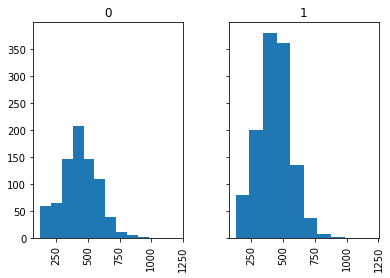

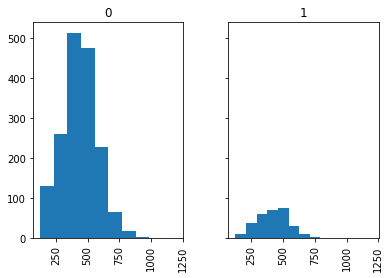

In [10]:
info_tb['old_shape_z'] = info_tb['old_shape'].apply(lambda x: int(x.split('_')[-1]))
ax_zsize = info_tb.hist('old_shape_z',  by = 'probCOVID', sharex = True, sharey = True)

ax_zsize_severe = info_tb.hist('old_shape_z',  by = 'probSevere', sharex = True, sharey = True)


In [ ]:
# info_tb.plot.scatter(x = 'SliceThickness', y = 'old_shape_z')
ax_zsize = info_tb.hist('SliceThickness',  by = 'probCOVID', sharex = True, sharey = True)

ax_zsize_severe = info_tb.hist('SliceThickness',  by = 'probSevere', sharex = True, sharey = True)

In [ ]:
covid_by_thick = pd.crosstab(info_tb['SliceThickness'], info_tb['probCOVID'])
print(covid_by_thick)
ax_thick = covid_by_thick.plot.bar(rot = 0,)

In [ ]:
severe_by_thick = pd.crosstab(info_tb['SliceThickness'], info_tb['probSevere'])
print(severe_by_thick)
ax_thick = severe_by_thick.plot.bar(rot = 0,)

<AxesSubplot:xlabel='new_spacing_z', ylabel='new_shape_z'>

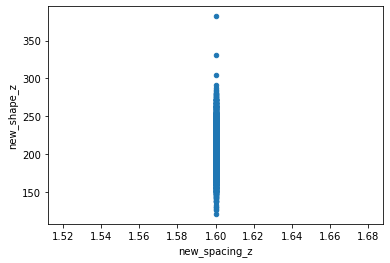

In [11]:
# 'new_shape', 'new_spacing',
info_tb['new_shape_z'] = info_tb['new_shape'].apply(lambda x: int(x.split('_')[-1]))
info_tb['new_spacing_z'] = info_tb['new_spacing'].apply(lambda x: float(x.split('_')[-1]))
info_tb.plot.scatter(x = 'new_spacing_z', y = 'new_shape_z')